# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import BorderlineSMOTE

# Load Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Pranjali kiran Bokad\Downloads\diabetes.csv")

In [3]:
df.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1


# Initial Exploration

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.dtypes

Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
Pedigree         float64
Age                int64
Outcome            int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.shape

(768, 9)

In [8]:
df.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Data Visualization

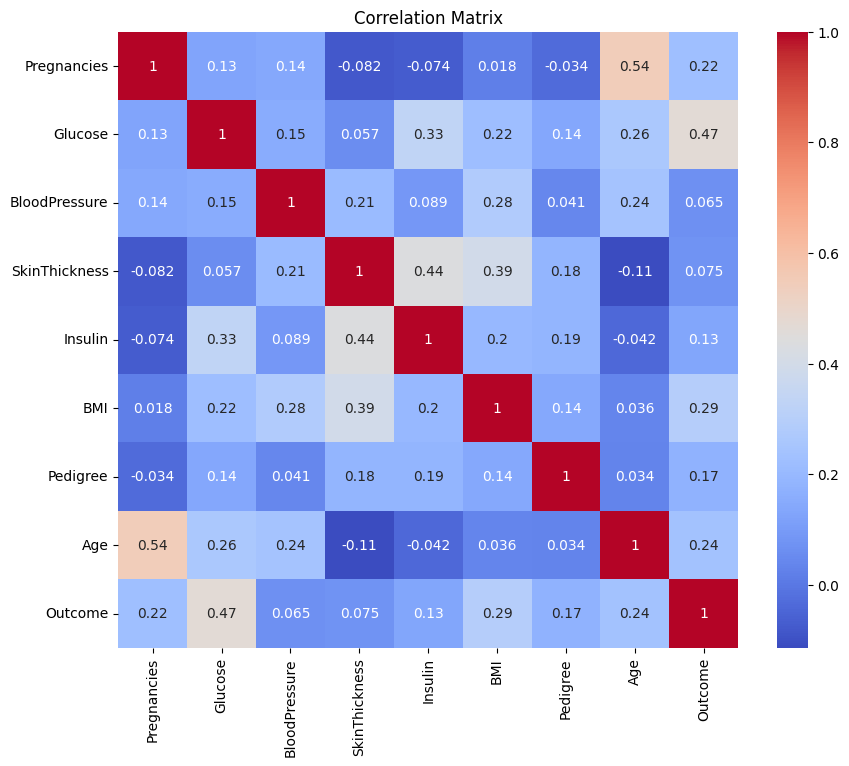

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


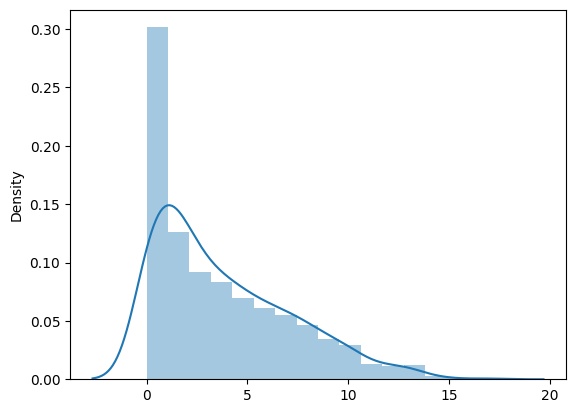

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


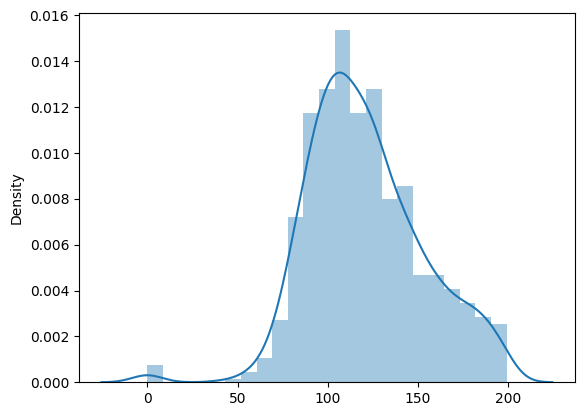

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


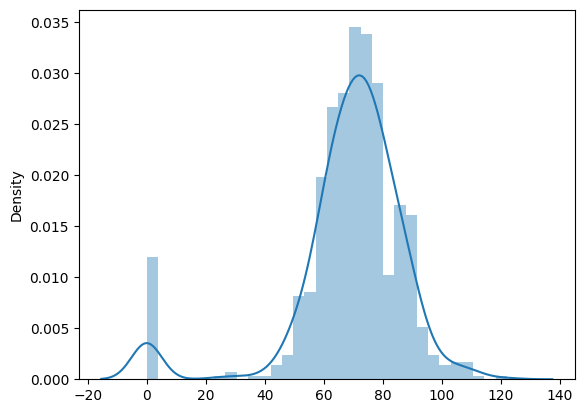

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


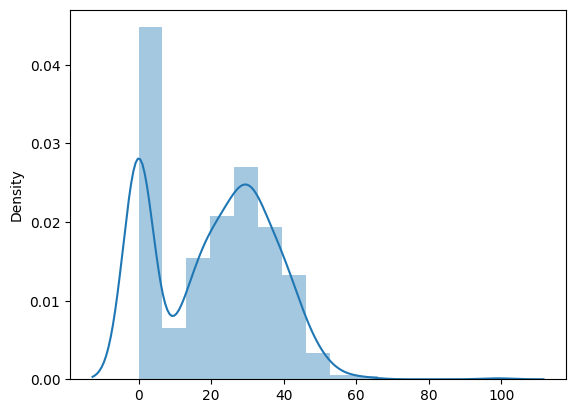

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


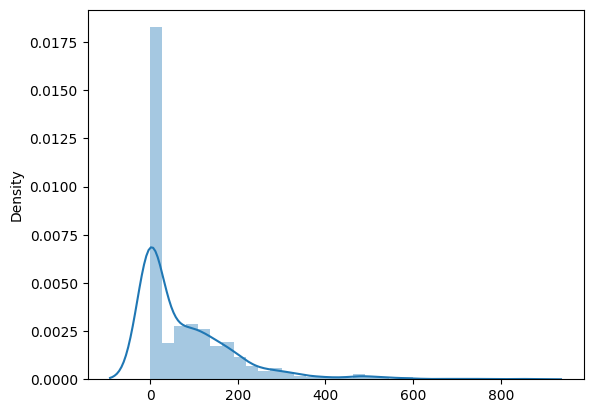

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


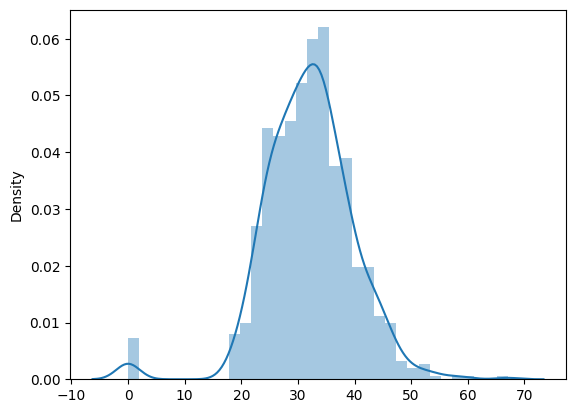

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


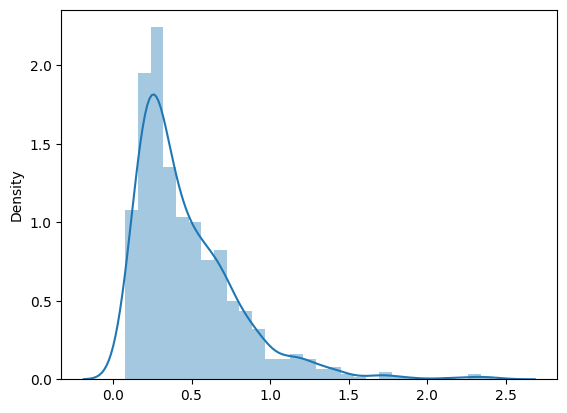

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


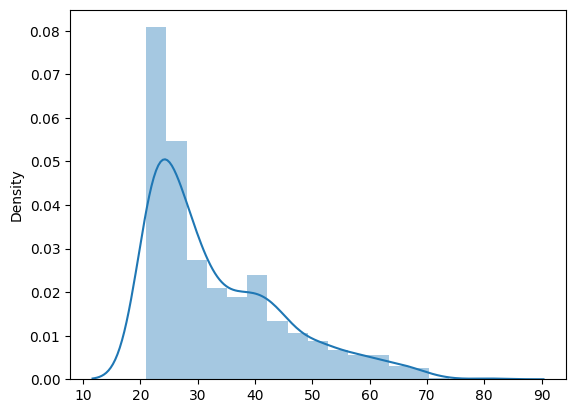

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_25960\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


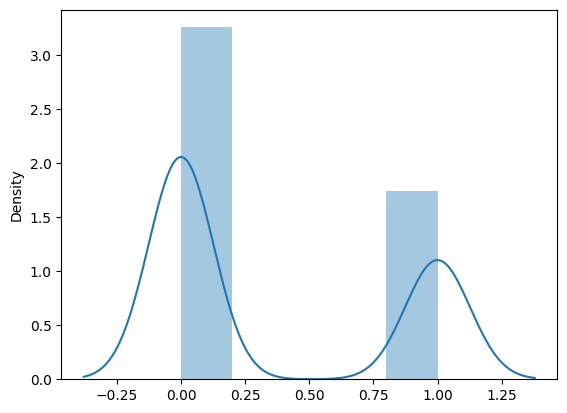

In [12]:
for i in df.select_dtypes(include=["int64","float64"]).columns:
    sns.distplot(x=df[i])
    plt.show()

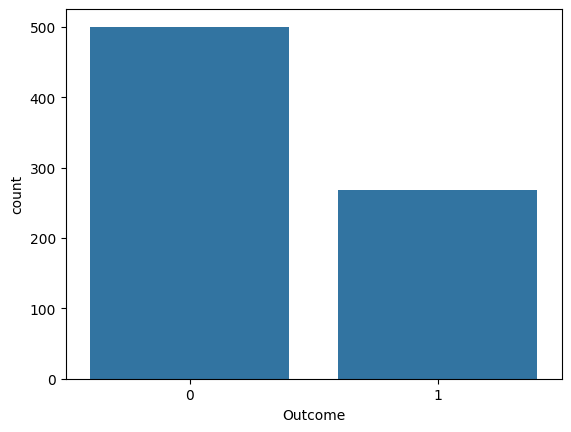

In [13]:
sns.countplot(x="Outcome",data=df)
plt.show()

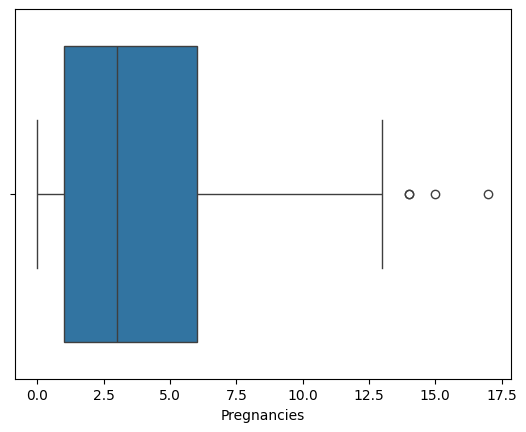

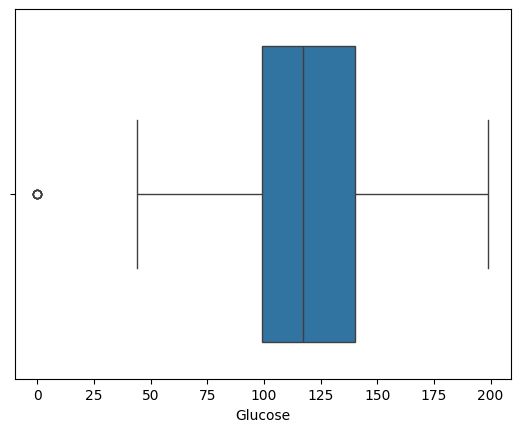

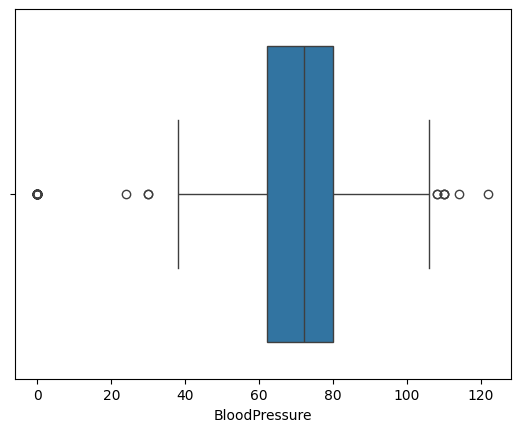

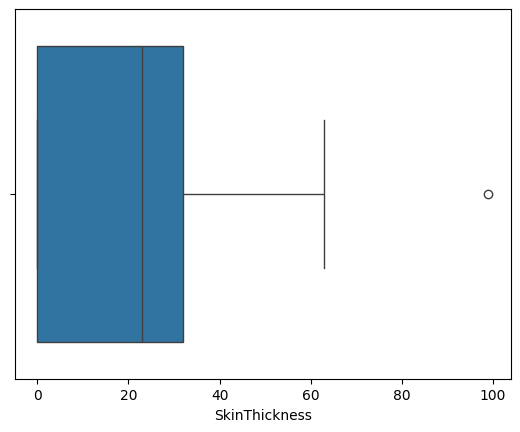

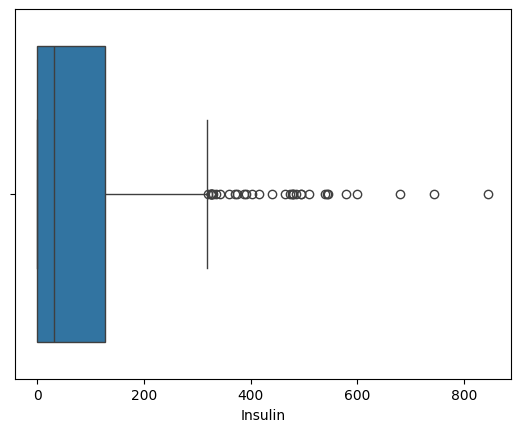

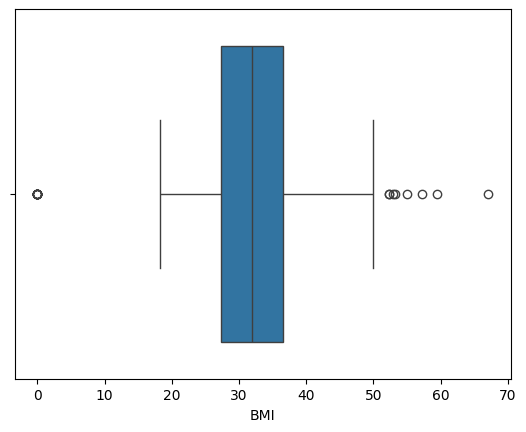

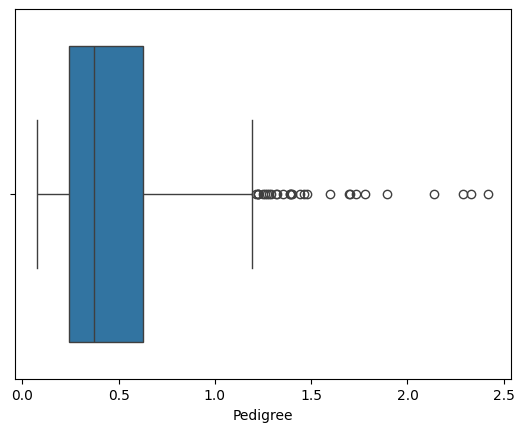

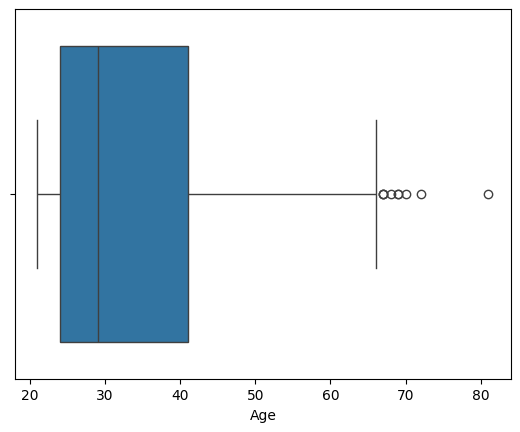

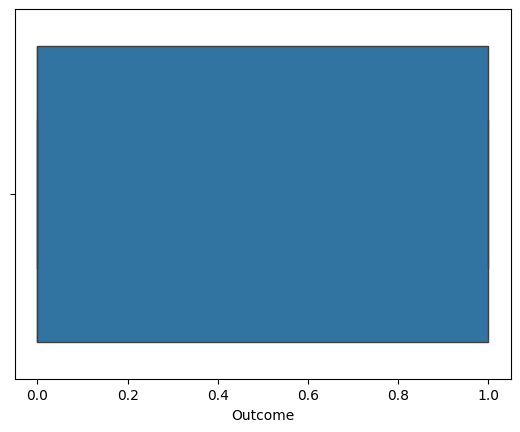

In [14]:
col_name=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]	

for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()

# Filling missing value

In [15]:
cols_with_zeros=["BloodPressure","SkinThickness","Insulin","Glucose","BMI"]

In [16]:
df[cols_with_zeros]=df[cols_with_zeros].replace(0,np.nan)
df[cols_with_zeros]=df[cols_with_zeros].fillna(df[cols_with_zeros].median())

# Feature engineering

In [17]:
df["BMI_Glucose"]=df["BMI"]*df["Glucose"]
df["Insulin_Glucose"]=df["Insulin"]/(df["Glucose"]+1)
df["Age_BMI"]=df["Age"]*df["BMI"]

In [18]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome,BMI_Glucose,Insulin_Glucose,Age_BMI
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,4972.8,0.838926,1680.0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2261.0,1.453488,824.6
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,4263.9,0.679348,745.6
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2500.9,1.044444,590.1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5904.7,1.217391,1422.3


# Train test split

In [19]:
x=df.drop("Outcome",axis=1)
y=df["Outcome"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

# Smote

In [20]:
print("Before saampling",np.bincount(y_train))
smote=BorderlineSMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)
print("After sampling",np.bincount(y_train_smote))

Before saampling [400 214]
After sampling [400 400]


# Model Training

In [21]:
model=XGBClassifier(n_estimators=350,max_depth=2,subsample=0.8,reg_lambda=1.5,learning_rate=0.03,colsample_bytree=0.8,random_state=42)
model.fit(X_train_smote,y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Threshold Tuning

In [23]:
y_prob = model.predict_proba(x_test)[:, 1]

for r in [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.30, 0.40, 0.50, 0.56]:
    y_pred_temp = (y_prob > r).astype(int)
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    fn = cm_temp[1,0]
    fp = cm_temp[0,1]
    recall = cm_temp[1,1] / (cm_temp[1,1] + cm_temp[1,0])
    print(f"threshold={r} | FN={fn} | FP={fp} | Recall={recall:.2f}")

threshold=0.12 | FN=1 | FP=62 | Recall=0.98
threshold=0.15 | FN=2 | FP=57 | Recall=0.96
threshold=0.18 | FN=3 | FP=55 | Recall=0.94
threshold=0.2 | FN=4 | FP=52 | Recall=0.93
threshold=0.22 | FN=4 | FP=51 | Recall=0.93
threshold=0.25 | FN=4 | FP=45 | Recall=0.93
threshold=0.3 | FN=7 | FP=43 | Recall=0.87
threshold=0.4 | FN=11 | FP=32 | Recall=0.80
threshold=0.5 | FN=16 | FP=24 | Recall=0.70
threshold=0.56 | FN=16 | FP=17 | Recall=0.70


In [36]:
y_pred=(y_prob>0.56).astype(int)

# Evaluation

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       100
           1       0.69      0.70      0.70        54

    accuracy                           0.79       154
   macro avg       0.76      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



In [38]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[83 17]
 [16 38]]


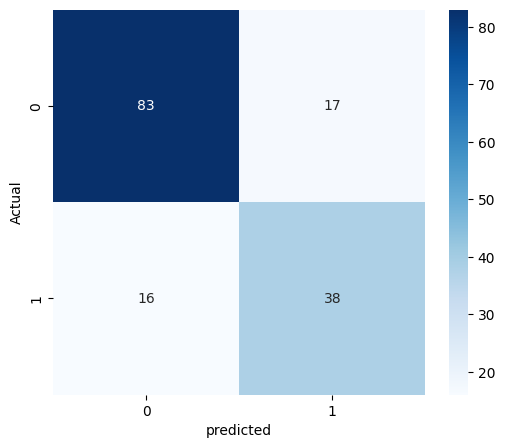

In [39]:
class_names=['0','1']

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
       xticklabels=class_names,
       yticklabels=class_names)
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

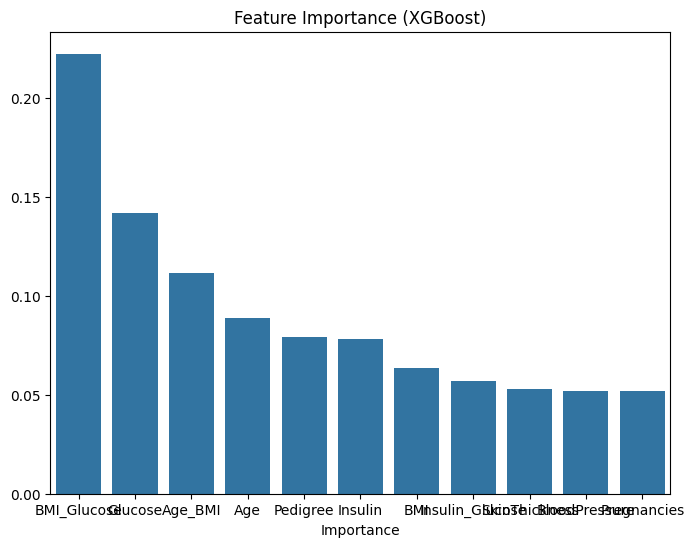

In [40]:
importances = pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.index, y=importances.values)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

### Accuracy model

In [41]:
np.mean(cross_val_score(model,x,y,scoring="accuracy",cv=5))

np.float64(0.7669637551990492)

In [42]:
x_train_pred=model.predict(x_train)
training_data_accuracy=accuracy_score(y_train,x_train_pred)
print('Accuracy score of the training data:',training_data_accuracy)

Accuracy score of the training data: 0.8420195439739414


In [43]:
x_test_pred=model.predict(x_test)
testing_data_accuracy=accuracy_score(y_test,x_test_pred)
print('Accuracy score of the testing data:',testing_data_accuracy)

Accuracy score of the testing data: 0.7402597402597403


### Making prediction system

In [44]:
input_data=(1,85,66,29,0,26.6,0.351,31,2261.0,0.000000,824.6)

input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==0):
    print('The person is not diabetic')
else:
     print('The person is diabetic')

[0]
The person is not diabetic
